In [1]:
%load_ext autoreload
%autoreload 2
import os

import torch

In [2]:
dataset = "mipnerf360"  # terrasky3D, mipnerf360, scannetpp
scene = "bicycle"  # vienna_state_opera, bicycle, bonsai, graz_townhall, graz_church, 40aec5fffa

images_path = f"demo_scenes/{dataset}/{scene}/images_150"
gt_path = f"demo_scenes/{dataset}/{scene}/sparse_150"
reconstruction_path = f"out/{scene}/sparse_vggt"
depths_path = f"out/{scene}/sparse_vggt/depths.pth"

print("Images path:", images_path)
print("Reconstruction path:", reconstruction_path)
print("Depths path:", depths_path)
print("GT path:", gt_path)

Images path: demo_scenes/mipnerf360/bicycle/images_150
Reconstruction path: out/bicycle/sparse_vggt
Depths path: out/bicycle/sparse_vggt/depths.pth
GT path: demo_scenes/mipnerf360/bicycle/sparse_150


In [3]:
from epo import EPO

epo = EPO(
    reconstruction_path=reconstruction_path,
    images_path=images_path,
    depths_path=depths_path,
    single_camera_per_folder=True,
    verbose=True,
    use_amp=True,
    backend="triton",  # or "torch". Note: "triton" backend is much faster but requires a compatible GPU and PyTorch version.
)

INFO:extractors.canny:CannyEdgeDetector initialized with low_threshold=0.15, high_threshold=0.2, hysteresis=True, kernel_size=9, sigma=2, device=cuda
INFO:helpers.load:Found 150 images in demo_scenes/mipnerf360/bicycle/images_150
DEBUG:epo:Edges stats: 60 images have more than 12,288 edges. max: 23,673 | min: 3,859 | avg: 11,357 | std: 4,252.16 | quantiles (0.5, 0.9): 10,380, 16,910
INFO:helpers.reprojection:Filtered viewgraph: 2,514/11,175 pairs retained
DEBUG:epo:Average degree: 33.52, min connections 6, images with fewer than 5 neighbors: 0
DEBUG:epo:Connected components: 1, sizes: [150] (dropped 0 images in components < 3)



Total parameters to optimize:
  R:                  0
  t:                  0
  mlp:           69,260
  k:                  1
  z:          3,686,400
-----------------------
  Total:      3,755,661



dict_keys(['image', 'coords', 'scale', 'hw', 'depth', 'confidence', 'cam_id', 'edges_map', 'edges', 'edges_padded', 'pad_mask', 'sampled_depth', 'dt_field'])


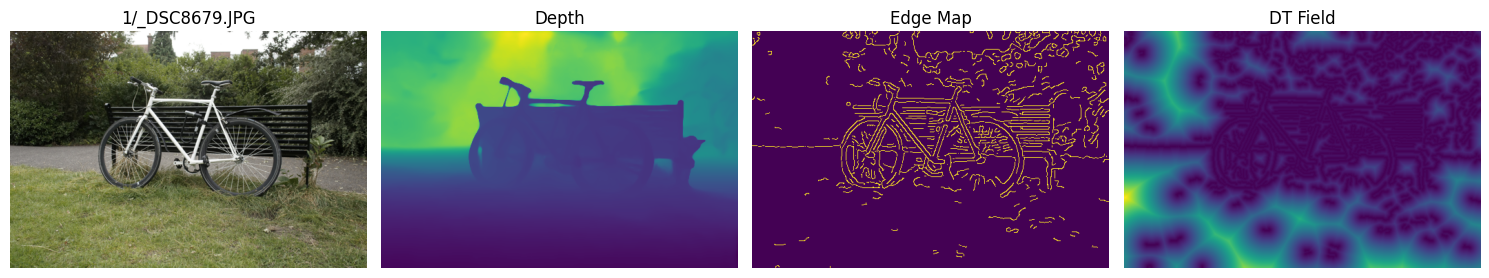

In [4]:
from mylib.plot import plot_imgs

keys = sorted(list(epo.images.keys()))
print(epo.images[keys[0]].keys())

for i in range(0, 150, 15):
    k = keys[i]
    rgb = (
        epo.images[k]["image"].permute(1, 2, 0).cpu()
        if "image" in epo.images[k]
        else torch.zeros_like(epo.images[k]["depth"]).permute(1, 2, 0).cpu()
    )
    depth = (
        epo.images[k]["depth"].cpu()
        if "depth" in epo.images[k]
        else torch.zeros_like(epo.images[k]["depth"]).cpu()
    )
    edges_map = (
        epo.images[k]["edges_map"].cpu()
        if "edges_map" in epo.images[k]
        else torch.zeros_like(epo.images[k]["depth"]).cpu()
    )
    dt_field = (
        epo.images[k]["dt_field"].cpu()
        if "dt_field" in epo.images[k]
        else torch.zeros_like(epo.images[k]["depth"]).cpu()
    )
    plot_imgs(
        [rgb, depth, edges_map, dt_field],
        titles=[k, "Depth", "Edge Map", "DT Field"],
        figsize=(15, 5),
    )
    break

In [5]:
epo(
    early_stop="pose",
    gt_path=gt_path,
)

DEBUG:epo:Processing 2,514 pairs with batch size 128 (20 batches per iteration). Using 12,288 edges per image. Total points to process per iteration: 30,892,032.
Optimizing:  23%|██▎       | 464/2000 [00:05<00:17, 85.80it/s, auc5=89.9840, loss=2.7065]



                          EPO  Summary                           
-----------------------------------------------------------------
                             LOADING                             
-----------------------------------------------------------------
  other (extractor load, GC…)        3.03s 100.0%              
total loading                        3.03s  30.5%              
-----------------------------------------------------------------
                       OPTIMIZATION  LOOP                        
-----------------------------------------------------------------
stage                                total  % opt    avg / iter
-----------------------------------------------------------------
  pre-compute  (unproject)             N/A    N/A           N/A
  batch inputs                         N/A    N/A           N/A
  forward  (project+Huber)             N/A    N/A           N/A
  loss aggregation                     N/A    N/A           N/A
  backward             

Max AUC@5: 90.01511889743543


(<Figure size 2400x300 with 4 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >,
        <Axes: xlabel='Optimization steps', ylabel='Change'>], dtype=object))

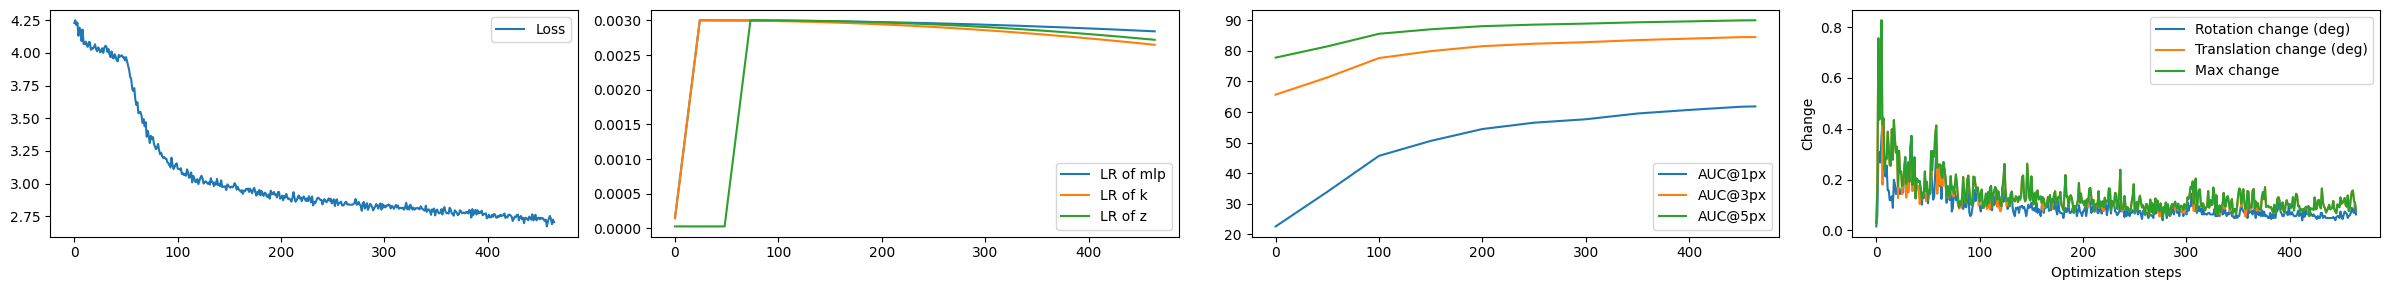

In [6]:
from helpers.demo_plotting import plot_training_summary

plot_training_summary(epo, auc_thresholds=(1, 3, 5))

(<Figure size 1400x400 with 2 Axes>,
 <Axes: title={'center': 'Training Convergence & Stability Metrics'}, xlabel='Steps', ylabel='Max Change (Delta)'>)

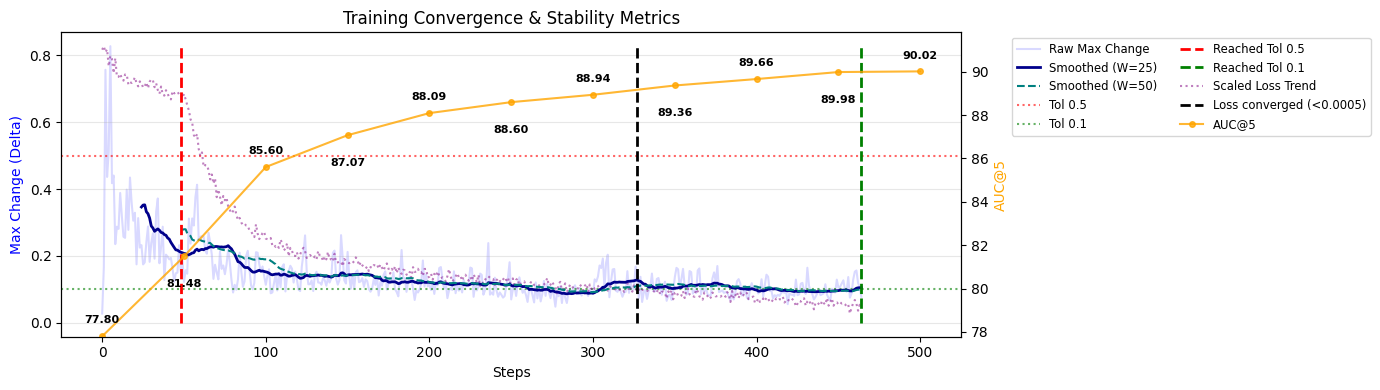

In [7]:
from helpers.demo_plotting import plot_training_convergence

# `epo` works as-is; pass a "training_logs.json" path or dict to replay a run.
plot_training_convergence(
    epo,
    window_pose=25,
    window_pose2=50,
    window_loss=25,
    tol_pose=0.5,
    tol_pose2=0.1,
    tol_loss=5e-4,
)

In [8]:
opt = f"out/{scene}/sparse_epo_nb"
os.makedirs(opt, exist_ok=True)

save_points = True  # recall to set mean track len = 0 in colmap gui

epo.to_colmap(
    opt,
    verbose=False,
    max_points_per_image=100_000 // len(epo.images),
    save_points=save_points,
    final_dbscan_filtering=False,
    dbscan_eps=0.1,
    dbscan_min_samples=5,
)

Reconstruction(num_rigs=1, num_cameras=1, num_frames=150, num_reg_frames=150, num_images=150, num_points3D=99900)

In [9]:
from helpers.benchmark_pose import eval_colmap_model

thresholds = [1, 3, 5]
models = {"VGGT": reconstruction_path, "VGGT+EPO": opt}

print("AUC@", thresholds)
dfs = {}
for label, path in models.items():
    auc, num_images, dfs[label] = eval_colmap_model(
        path, gt_path, return_df=True, thrs=thresholds
    )
    print(f"{label:<8}", [round(float(a), 2) for a in auc])

df_initial, df_optim = dfs["VGGT"], dfs["VGGT+EPO"]

AUC@ [1, 3, 5]
VGGT     [22.55, 65.68, 77.8]
VGGT+EPO [61.83, 84.53, 90.02]
